# CD94 co-expression

Doing some analyses for Zach Hopkins. Background from his email on 7/24/26:

* "It would be interesteing to see which CD8+ t-cells have CD94 and which ones do not. It would be interesting to see these spatially (i.e. where in the infiltrate are these CD94+ cells, are they adjacent to apoptotic keratinocytes? Etc." 
* "Quantitatively, it would be interesting to see degree of expression perhaps across CD8+ T-cell types and NK cells"
* Look at where CD94 co-associates, i.e is it on more 
    (a) Cytotoxic CD8+ t-cells (expressing GZMB, PRF1, GNLY, NKG7, CTSW, IFNG, CCL5) 
    (b) Tissue resident: CD69, ITGAE/CD103, CXCR6, ZNF683, RUNX3
    (c) Cells with more markers of activation (IFNG, TNF, FOS, JUN, CD69) 
    (d) Memory cells (IL7R, TCF7, LTB, CCR7) 

# Environment

In [15]:
import os
os.chdir('/Users/burkelawlor/Repos/hci-xenium')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import spatialdata_plot

from utils.data_loading import *
from utils.spatial import *

# Load data

In [2]:
samples = [
    'LP1_LP2','LP3','LP4','LP5','LP6','LP7','LP8',
    # 'NS1','NS2','NS3','NS4',
]

In [16]:
adata = ad.read_h5ad("./data/processed/adata/lp+yale_2_annotated.h5ad")

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# # Load sdata and add annotations
# sdata_dict = {}

# for sample_name in samples:
#     print(sample_name)
#     print(xenium_paths[sample_name])

#     sdata = load_sdata_from_xenium(sample_name, merge_adata=adata_lp, add_he_image=False)
    
    
#     if sample_name == 'LP1_LP2':
    
#         sdata_dict['LP1'] = sdata.query.bounding_box(
#             axes=["x", "y"],
#             min_coordinate=[0, 0],
#             max_coordinate=[21500, 29000],
#             target_coordinate_system="global",
#         )

#         sdata_dict['LP2'] = sdata.query.bounding_box(
#             axes=["x", "y"],
#             min_coordinate=[21500, 0],
#             max_coordinate=[25717.0, 29000],
#             target_coordinate_system="global",
#         )

#     else:
#         sdata_dict[sample_name] = sdata

#     print()
#     print('-'*100)

#     break

# Finding CD94+ cells

Note: KLRD1 encodes CD94

In [12]:
adata.var_names.str.contains('KLRD1').sum()

np.int64(1)

# KLRD1 expression distribution

In [ ]:
gene = 'KLRD1'
klrd1_expr = adata[:, gene].X.toarray().flatten()

Normalized counts
count    488843.000000
mean          0.005275
std           0.068163
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.619708
dtype: float64


<Axes: >

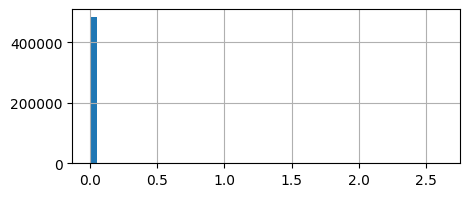

In [76]:
norm_counts = pd.Series(adata[:, gene].X.toarray().flatten())
print('Normalized counts')
print(norm_counts.describe())
norm_counts.hist(bins=50, figsize=(5, 2))


Raw counts
count    488843.000000
mean          0.009148
std           0.114859
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
dtype: float64


<Axes: >

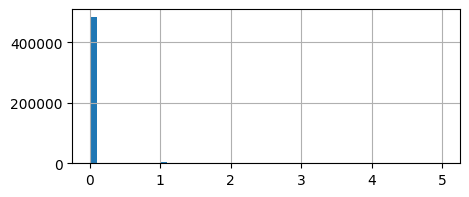

In [77]:
raw_counts = pd.Series(adata[:, gene].layers['raw_counts'].toarray().flatten())
print('Raw counts')
print(raw_counts.describe())
raw_counts.hist(bins=50, figsize=(5, 2))

                        pct  n_cells  n_expressed
ct_detailed                                      
Melanocytes        0.062657     1596            1
Pericytes          0.068760    17452           12
Schwann cells      0.070584     5667            4
Sweat gland        0.073584     8154            6
Langerhans         0.080000     2500            2
Mast cells         0.102712     4868            5
Granular KCs       0.135772    12521           17
Sebocytes          0.138825     4322            6
Plasmacytoid DCs   0.208943     2393            5
CLEC10A+ DCs       0.231481    12528           29
Lymphatic ECs      0.255604     5086           13
Basal KCs          0.281944    35468          100
Spinous KCs        0.285200    59958          171
Fibroblasts        0.326774    69773          228
Tregs              0.333333    15300           51
B cells            0.357873     1956            7
Plasma cells       0.383772     1824            7
Vascular ECs       0.414573    28463          118


/var/folders/l8/r_bqmkfd36n6y9mvy600d2580000gn/T/ipykernel_28095/3350492247.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby)['expressed']


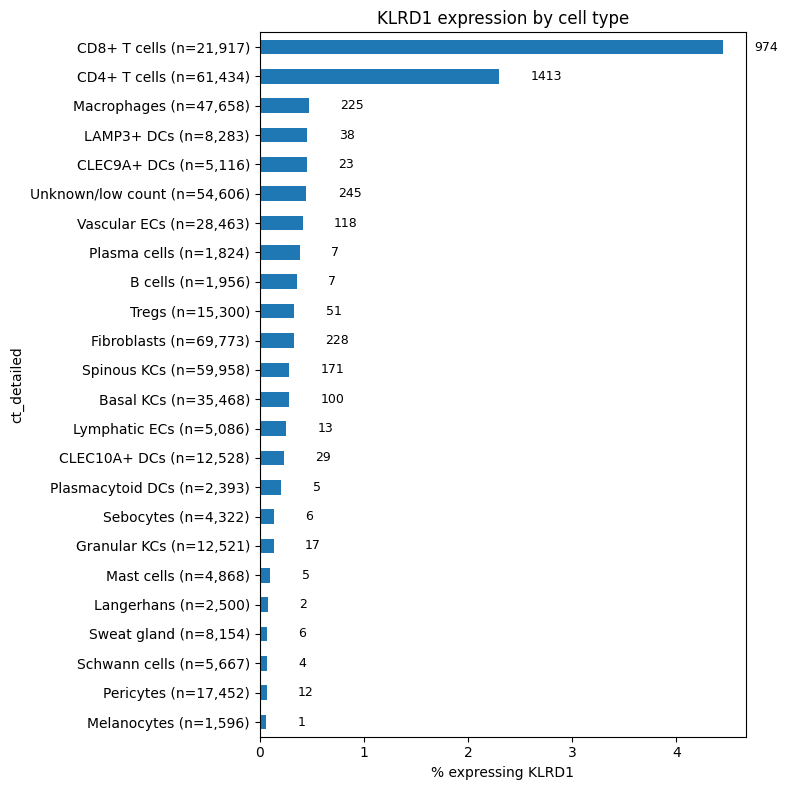

In [132]:
gene = 'KLRD1'
groupby = 'ct_detailed'

expressed = sc.get.obs_df(adata, keys=[gene])[gene].values > 0

pct_df = (
    adata.obs[[groupby]]
    .assign(expressed=expressed)
    .groupby(groupby)['expressed']
    .agg(pct=lambda x: x.mean() * 100, n_cells='count', n_expressed='sum')
    .sort_values('pct', ascending=True)
)
print(pct_df)

# Plots
fig, ax = plt.subplots(figsize=(8, 8))
pct_df['pct'].plot(kind='barh', ax=ax)

ax.set_yticklabels(
    [f"{ct} (n={pct_df.loc[ct, 'n_cells']:,})" for ct in pct_df.index]
)

for i, (_, row) in enumerate(pct_df.iterrows()):
    ax.text(row['pct'] + 0.3, i, str(int(row['n_expressed'])),
            va='center', ha='left', fontsize=9)

ax.set_xlabel(f'% expressing {gene}')
ax.set_title(f'{gene} expression by cell type')
plt.tight_layout()
plt.show()

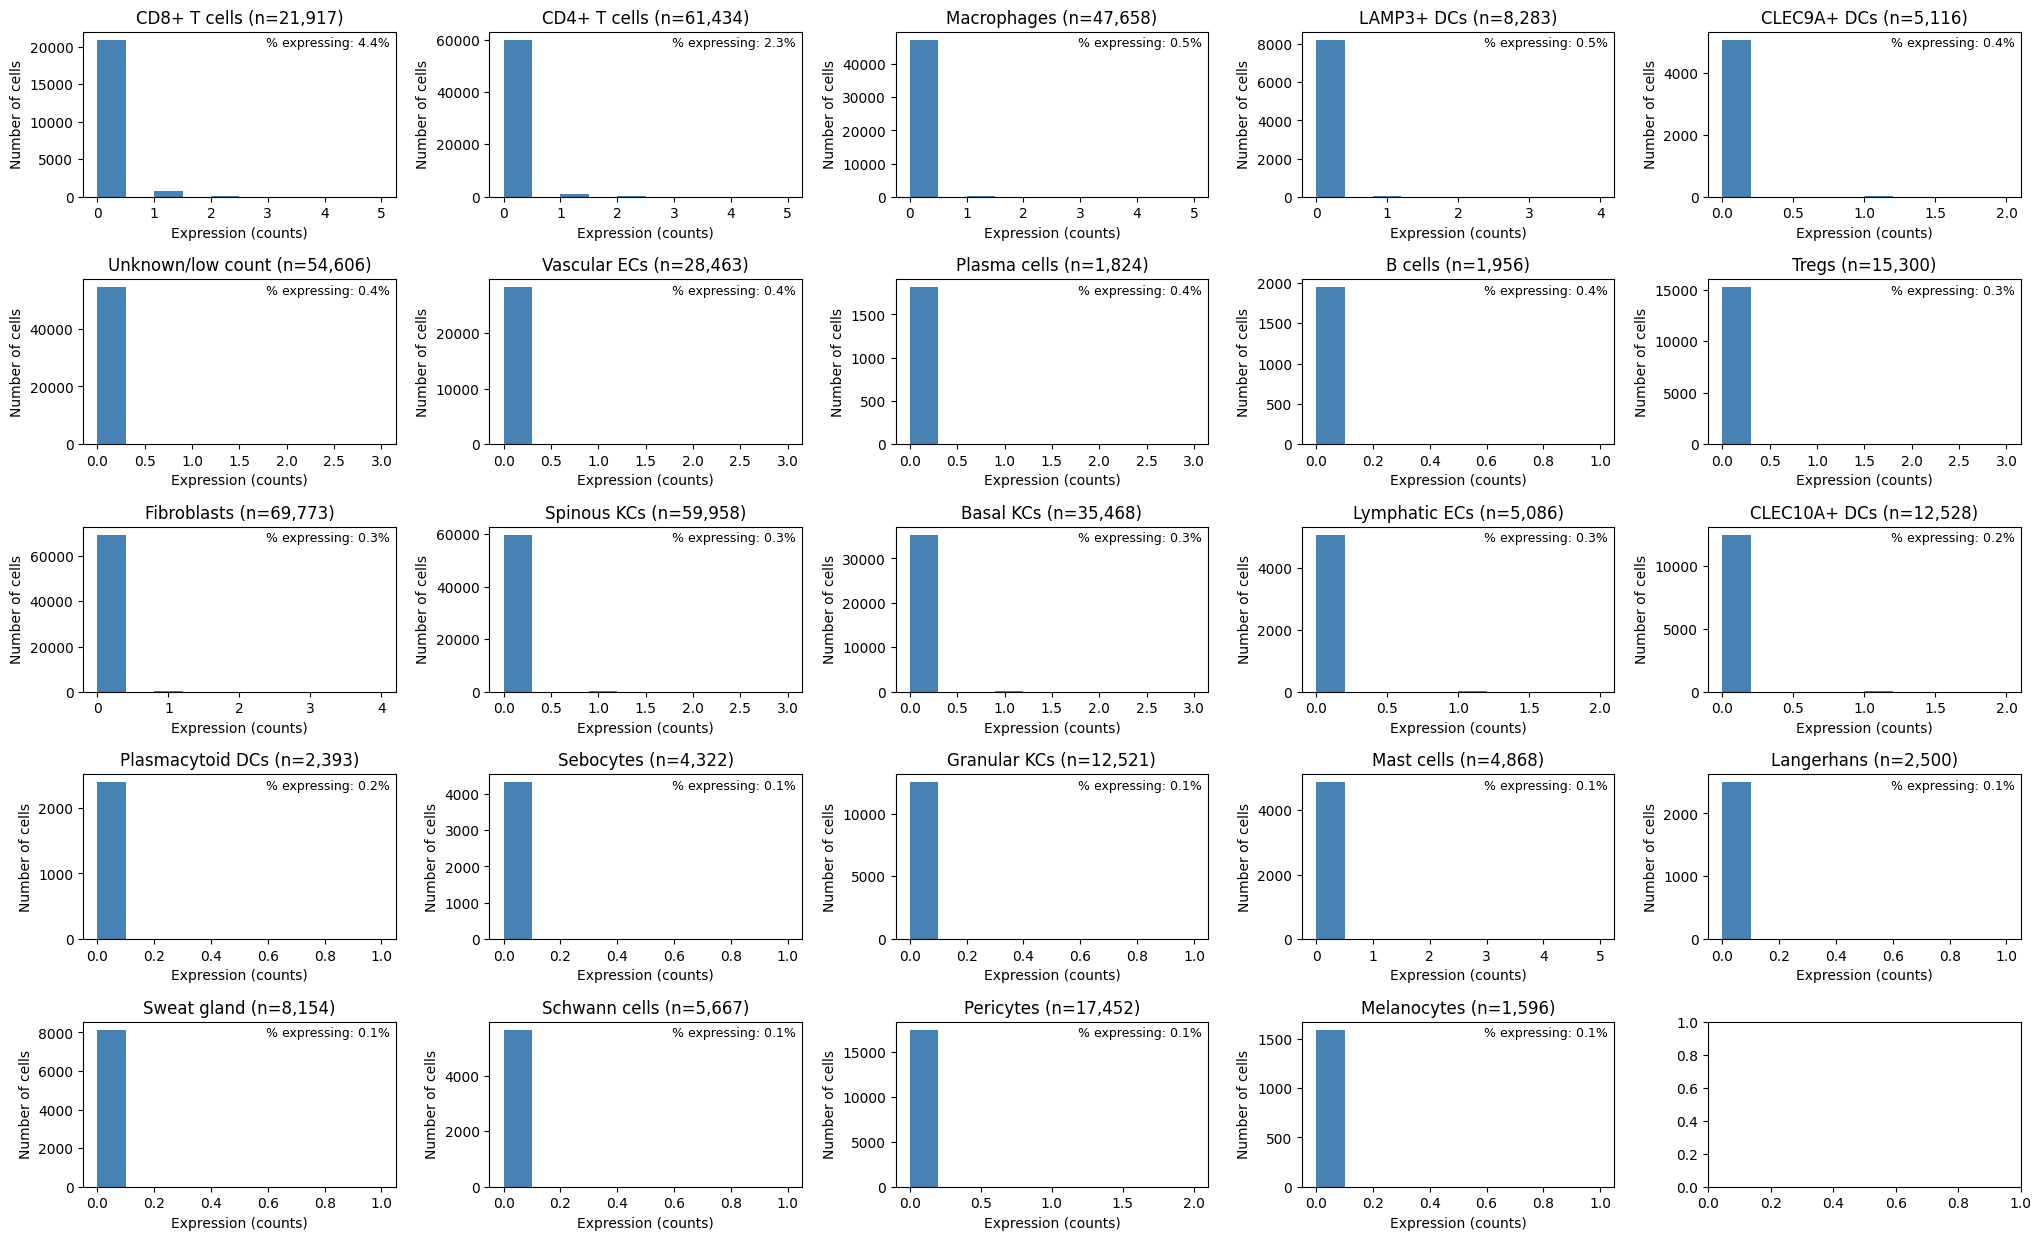

In [139]:
cts = pct_df.sort_values('pct', ascending=False).index
ncols = 5
nrows = (len(cts) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3))
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # Add horizontal space between columns

for i, ct in enumerate(cts):
    ax = axes[i // ncols, i % ncols]
    ct_mask = adata.obs['ct_detailed'] == ct
    ct_expr = adata[ct_mask, gene].layers['raw_counts'].toarray().flatten()
    ax.hist(ct_expr, color='steelblue', edgecolor='none')
    ax.set_xlabel('Expression (counts)')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'{ct} (n={ct_mask.sum():,})')
    ax.text(0.98, 0.97, f'% expressing: {(ct_expr > 0).mean()*100:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

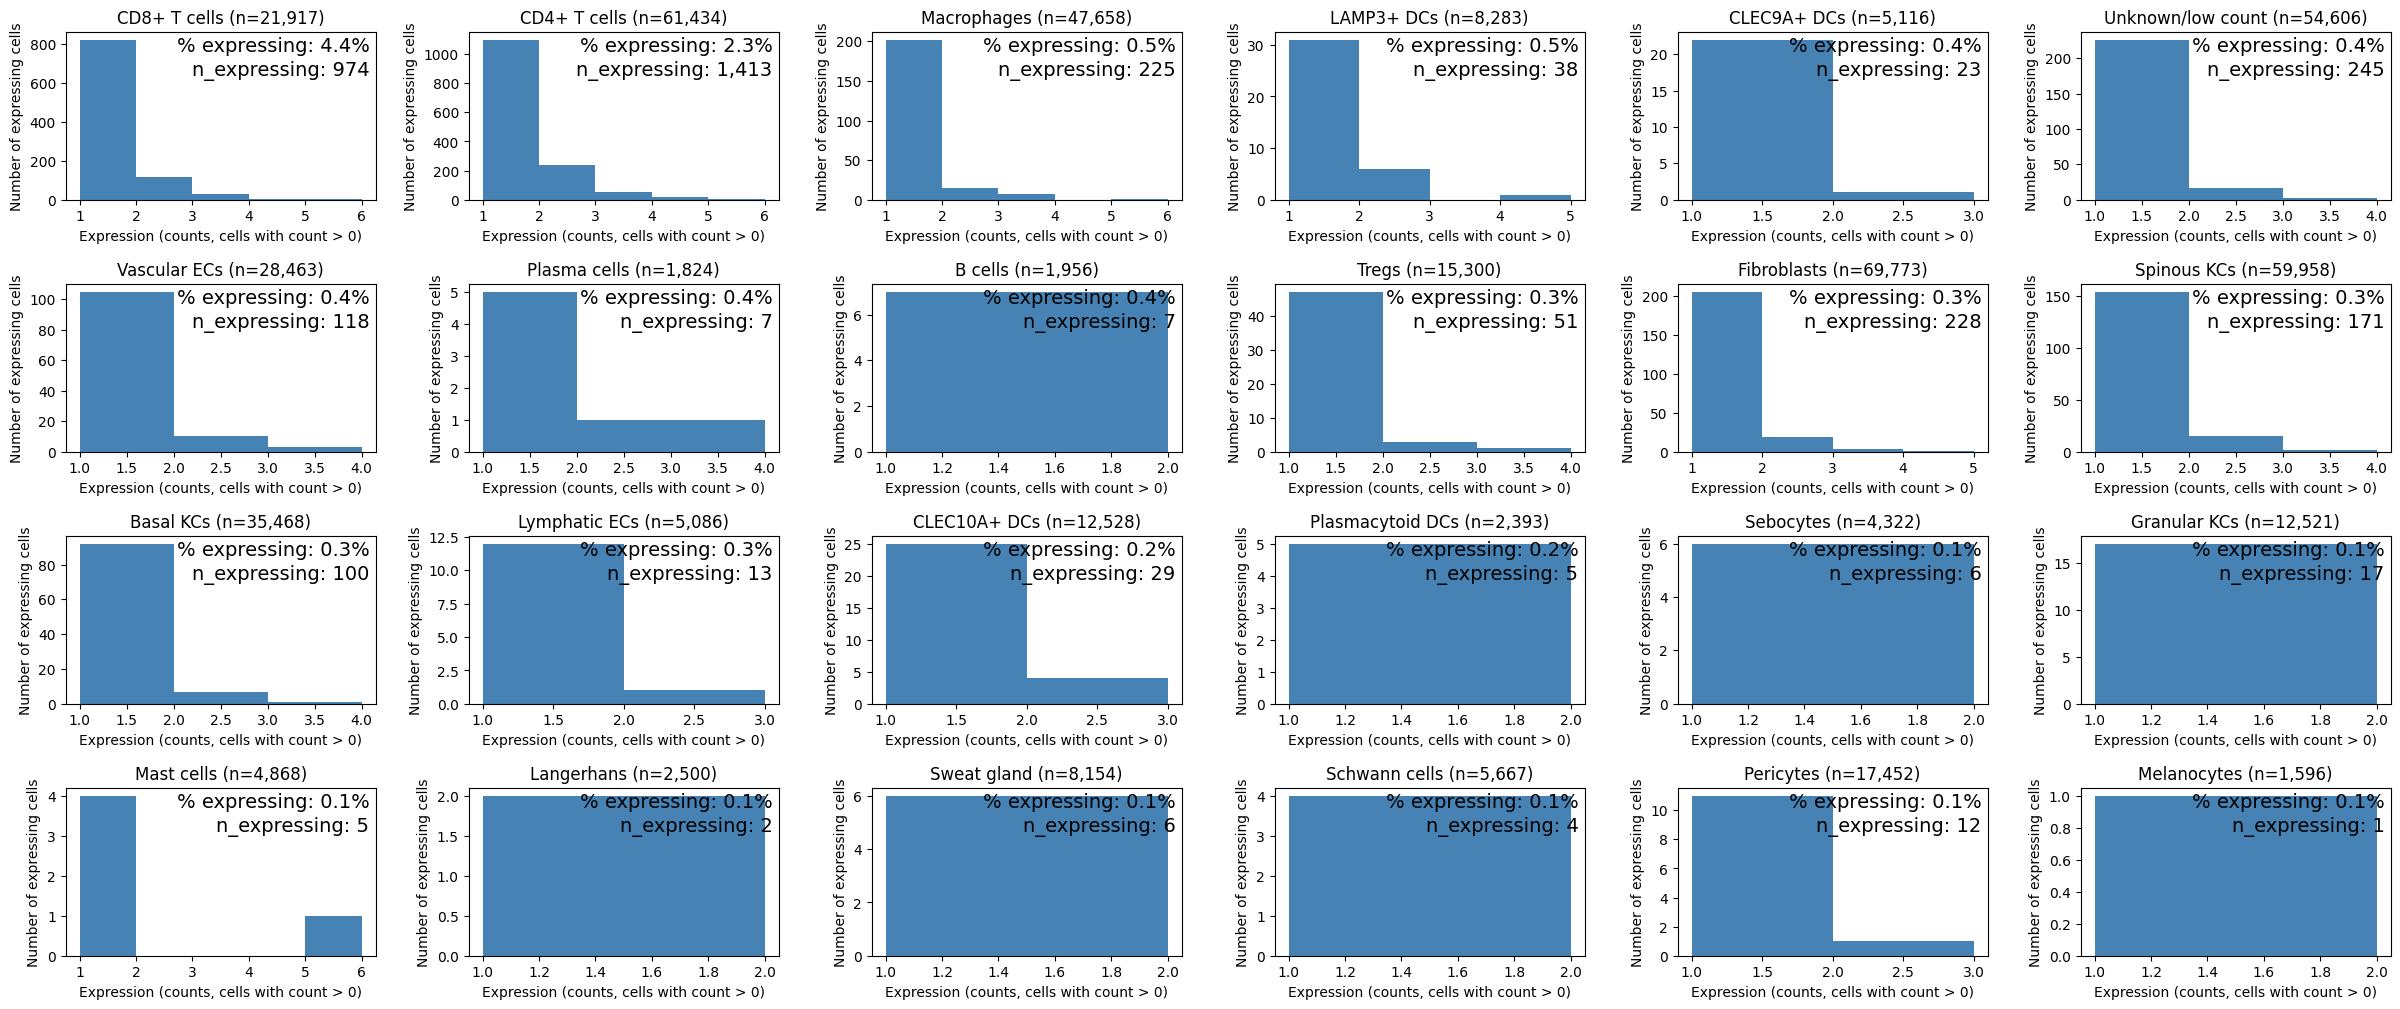

In [142]:
cts = pct_df.sort_values('pct', ascending=False).index
ncols = 6
nrows = (len(cts) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

for i, ct in enumerate(cts):
    ax = axes[i // ncols, i % ncols]
    ct_mask = adata.obs['ct_detailed'] == ct
    ct_expr = adata[ct_mask, gene].layers['raw_counts'].toarray().flatten()
    ct_expr_pos = ct_expr[ct_expr > 0]

    if len(ct_expr_pos) > 0:
        max_val = int(ct_expr_pos.max())
        bins = range(1, max_val + 2)  # integer bins since counts are discrete
        ax.hist(ct_expr_pos, bins=bins, color='steelblue', edgecolor='none')
    else:
        ax.text(0.5, 0.5, 'no expressing cells', transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='gray')

    ax.set_xlabel('Expression (counts, cells with count > 0)')
    ax.set_ylabel('Number of expressing cells')
    ax.set_title(f'{ct} (n={ct_mask.sum():,})')
    ax.text(0.98, 0.97, f'% expressing: {(ct_expr > 0).mean()*100:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=14)
    ax.text(0.98, 0.83, f'n_expressing: {(ct_expr > 0).sum():,}',
            transform=ax.transAxes, ha='right', va='top', fontsize=14)

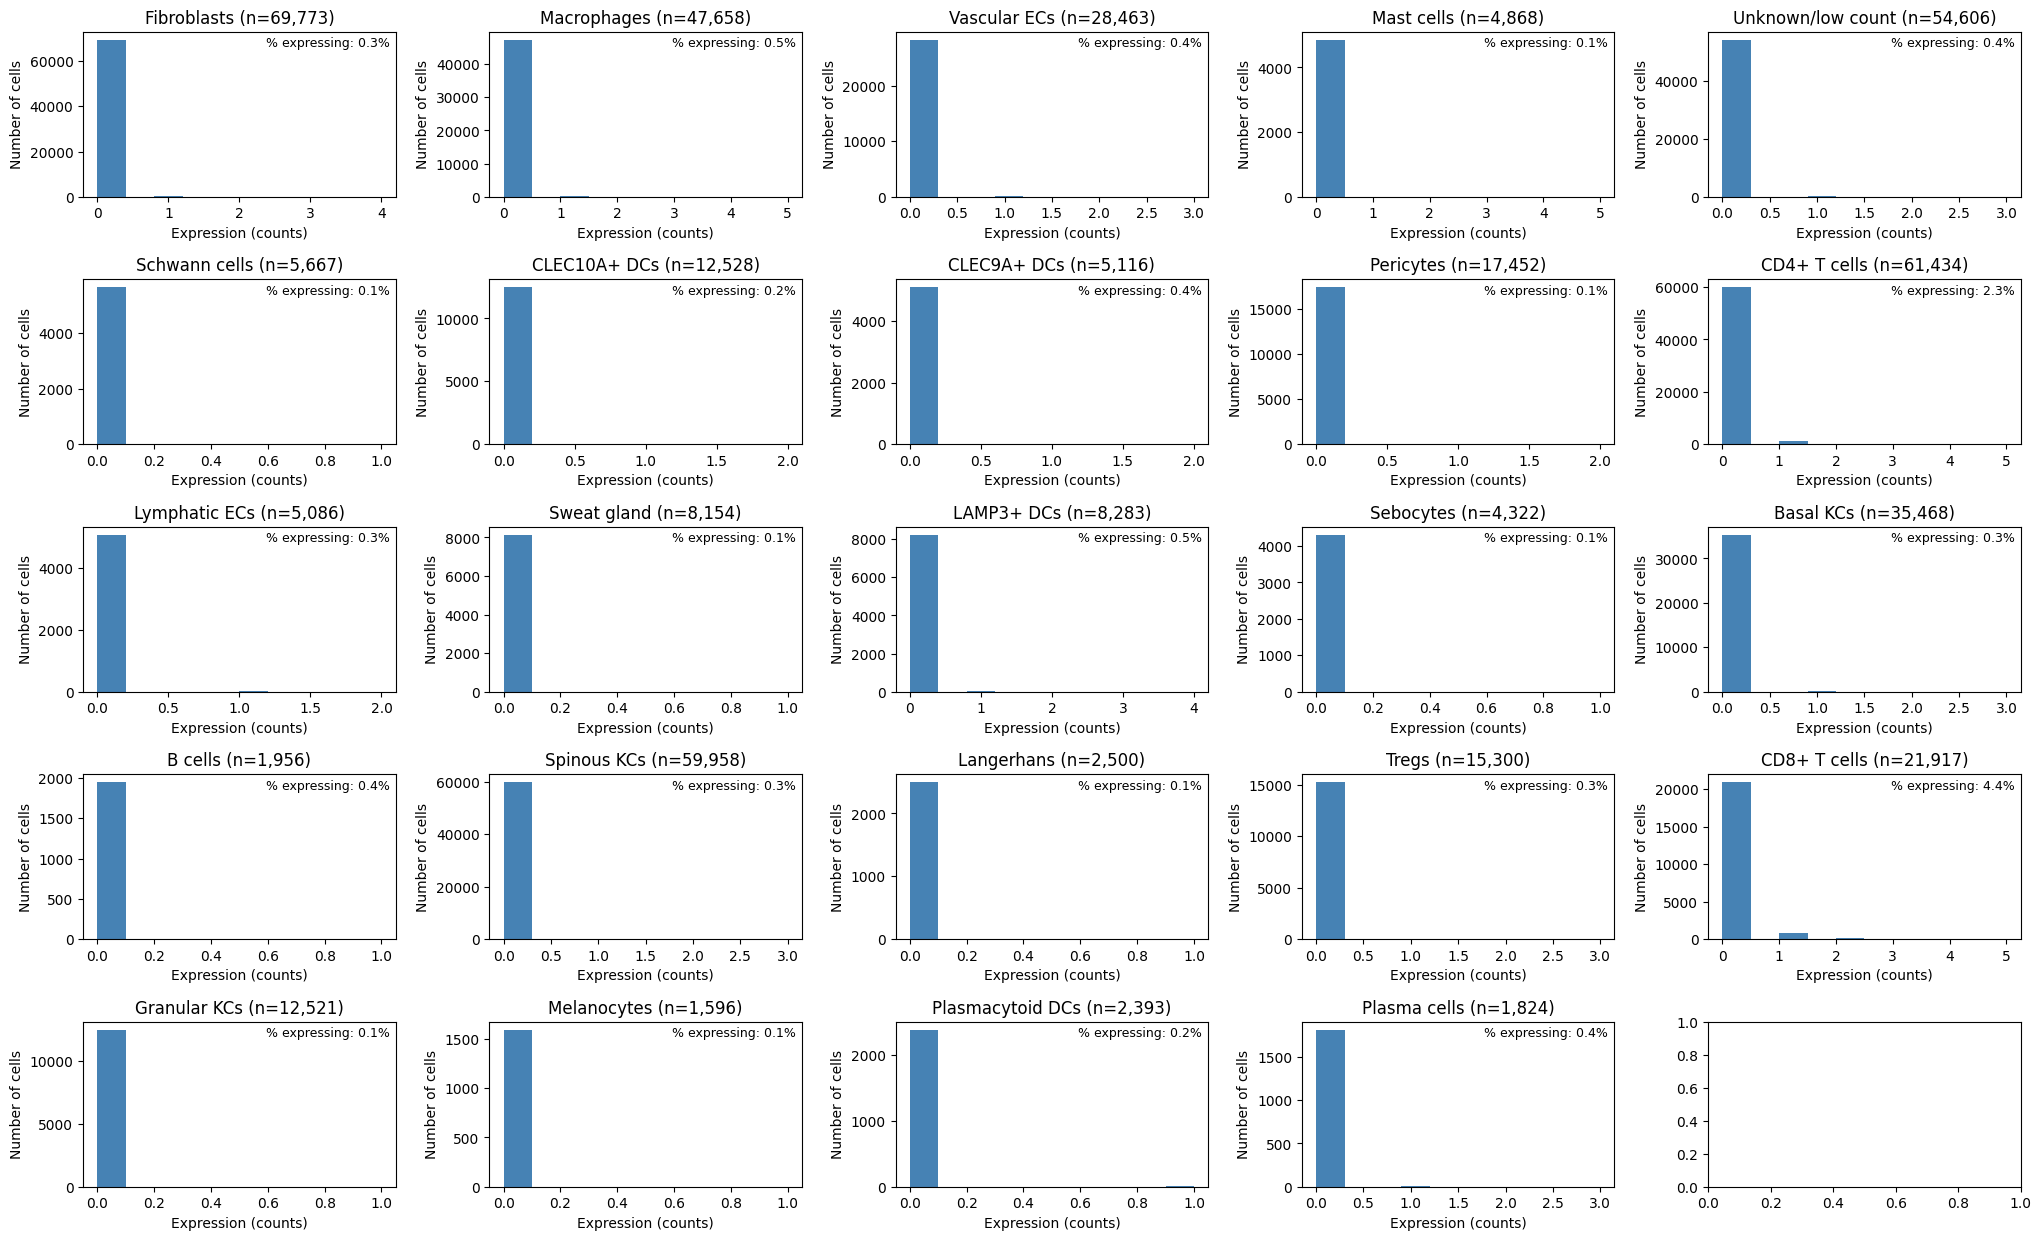

In [103]:
cts = adata.obs['ct_detailed'].unique()
ncols = 5
nrows = (len(cts) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3))
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # Add horizontal space between columns

for i, ct in enumerate(cts):
    ax = axes[i // ncols, i % ncols]
    ct_mask = adata.obs['ct_detailed'] == ct
    ct_expr = adata[ct_mask, gene].layers['raw_counts'].toarray().flatten()
    ax.hist(ct_expr, color='steelblue', edgecolor='none')
    ax.set_xlabel('Expression (counts)')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'{ct} (n={ct_mask.sum():,})')
    ax.text(0.98, 0.97, f'% expressing: {(ct_expr > 0).mean()*100:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

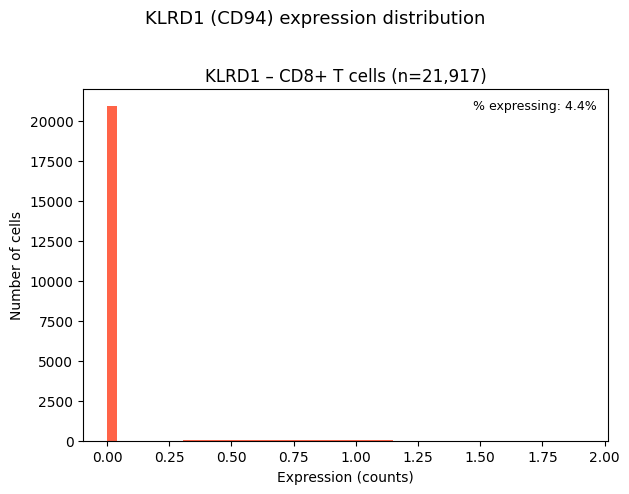

In [79]:
# 3. CD8+ T cells only
fig, ax = plt.subplots()
cd8_mask = adata.obs['ct_detailed'] == 'CD8+ T cells'
cd8_expr = adata[cd8_mask, gene].X.toarray().flatten()
ax.hist(cd8_expr, bins=50, color='tomato', edgecolor='none')
ax.set_xlabel('Expression (counts)')
ax.set_ylabel('Number of cells')
ax.set_title(f'{gene} – CD8+ T cells (n={cd8_mask.sum():,})')
ax.text(0.98, 0.97, f'% expressing: {(cd8_expr > 0).mean()*100:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle(f'{gene} (CD94) expression distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Text(0.98, 0.97, '% expressing: 0.8%')

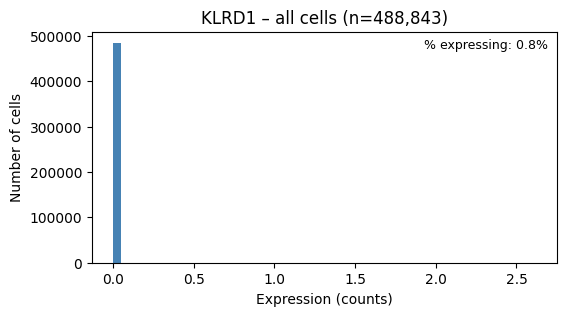

In [21]:
fig, ax = plt.subplots(figsize=(6, 3))

# 1. All cells
ax.hist(klrd1_expr, bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('Expression (counts)')
ax.set_ylabel('Number of cells')
ax.set_title(f'{gene} – all cells (n={len(klrd1_expr):,})')
ax.text(0.98, 0.97, f'% expressing: {(klrd1_expr > 0).mean()*100:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)


KeyError: 'sample_id'

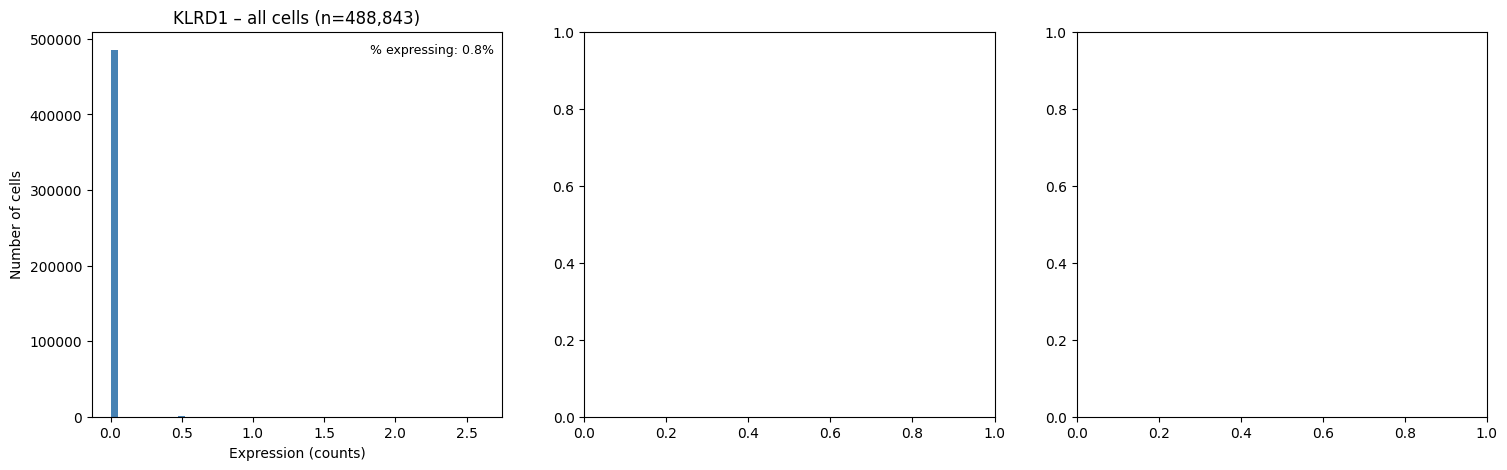

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. All cells
ax = axes[0]
ax.hist(klrd1_expr, bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('Expression (counts)')
ax.set_ylabel('Number of cells')
ax.set_title(f'{gene} – all cells (n={len(klrd1_expr):,})')
ax.text(0.98, 0.97, f'% expressing: {(klrd1_expr > 0).mean()*100:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)

# 2. Per sample
ax = axes[1]
samples_in_data = adata.obs['sample'].unique() if 'sample' in adata.obs.columns else adata.obs['sample_id'].unique()
sample_col = 'sample' if 'sample' in adata.obs.columns else 'sample_id'
sample_data = []
sample_labels = []
for s in sorted(adata.obs[sample_col].unique()):
    mask = adata.obs[sample_col] == s
    expr = adata[mask, gene].X.toarray().flatten()
    sample_data.append(expr)
    sample_labels.append(s)

ax.boxplot(sample_data, labels=sample_labels, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='black'),
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_xlabel('Sample')
ax.set_ylabel('Expression (counts)')
ax.set_title(f'{gene} – per sample')
ax.tick_params(axis='x', rotation=45)

# 3. CD8+ T cells only
ax = axes[2]
cd8_mask = adata.obs['ct_detailed'] == 'CD8+ T cells'
cd8_expr = adata[cd8_mask, gene].X.toarray().flatten()
ax.hist(cd8_expr, bins=50, color='tomato', edgecolor='none')
ax.set_xlabel('Expression (counts)')
ax.set_ylabel('Number of cells')
ax.set_title(f'{gene} – CD8+ T cells (n={cd8_mask.sum():,})')
ax.text(0.98, 0.97, f'% expressing: {(cd8_expr > 0).mean()*100:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle(f'{gene} (CD94) expression distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()